## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import EXP_neuro_fuzzy_toolbox as nft

## Data

In [2]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[-5.6075e-01,  7.7908e-01, -7.1840e-01],
        [ 7.2299e-01, -7.5550e-01, -2.5360e-01],
        [-3.9881e-02,  4.0566e-01, -7.3914e-01],
        [ 5.4214e-01,  7.8401e-01, -9.2078e-01],
        [ 9.9160e-01,  9.4088e-01,  8.5439e-01],
        [ 5.3688e-01, -4.7105e-01, -3.5233e-01],
        [ 5.5648e-02,  9.1434e-01,  1.9319e-01],
        [-1.5334e-01,  5.1540e-01,  4.3183e-01],
        [-2.3301e-01,  6.3806e-01, -6.8042e-01],
        [-8.1555e-01, -2.5338e-01, -3.4107e-01],
        [ 3.3226e-01, -7.6186e-01,  4.6078e-01],
        [ 3.5943e-01, -8.3055e-01,  8.6333e-01],
        [ 6.8110e-01,  1.1606e-01, -5.0623e-01],
        [-8.9547e-01,  6.3511e-01, -6.3790e-01],
        [-9.8132e-01,  2.9788e-02,  9.3380e-01],
        [-2.3418e-01,  4.3352e-01,  3.3840e-01],
        [ 8.6787e-01, -8.1543e-01,  8.0722e-01],
        [-4.0755e-01,  2.3097e-03, -2.7692e-01],
        [ 6.7305e-01, -6.0433e-01, -6.0960e-01],
        [-5.8284e-02,  3.6860e-02,  2.0007e-01],
        [ 6.5833e-01

In [3]:
y_train = torch.rand(200)
y_train

tensor([0.3466, 0.0136, 0.5019, 0.2672, 0.4873, 0.3650, 0.3125, 0.2924, 0.2015,
        0.5163, 0.6772, 0.2878, 0.5446, 0.5998, 0.0925, 0.8337, 0.9152, 0.8556,
        0.6378, 0.0146, 0.3270, 0.0065, 0.5233, 0.2931, 0.8207, 0.2521, 0.6851,
        0.2603, 0.6842, 0.6036, 0.0220, 0.5852, 0.4131, 0.2194, 0.6802, 0.2602,
        0.0116, 0.6821, 0.6780, 0.6823, 0.1068, 0.6466, 0.5566, 0.3451, 0.6640,
        0.5501, 0.9686, 0.0304, 0.2160, 0.2651, 0.5250, 0.2766, 0.8503, 0.1500,
        0.9719, 0.2385, 0.7231, 0.5081, 0.9768, 0.0480, 0.6392, 0.0386, 0.1242,
        0.0777, 0.2263, 0.0352, 0.0809, 0.2925, 0.0804, 0.8934, 0.9641, 0.9564,
        0.0493, 0.2039, 0.1034, 0.5095, 0.6644, 0.6609, 0.4019, 0.8063, 0.9128,
        0.7381, 0.8753, 0.8193, 0.7104, 0.3304, 0.0350, 0.9830, 0.7964, 0.7223,
        0.9339, 0.3023, 0.3995, 0.9779, 0.6639, 0.7241, 0.8198, 0.3509, 0.8869,
        0.8596, 0.8963, 0.3486, 0.5505, 0.2250, 0.2007, 0.2175, 0.0833, 0.1249,
        0.5715, 0.4358, 0.8197, 0.2422, 

## Model

In [31]:
mf_distribution = [2, 3, 2]

In [32]:
model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
)

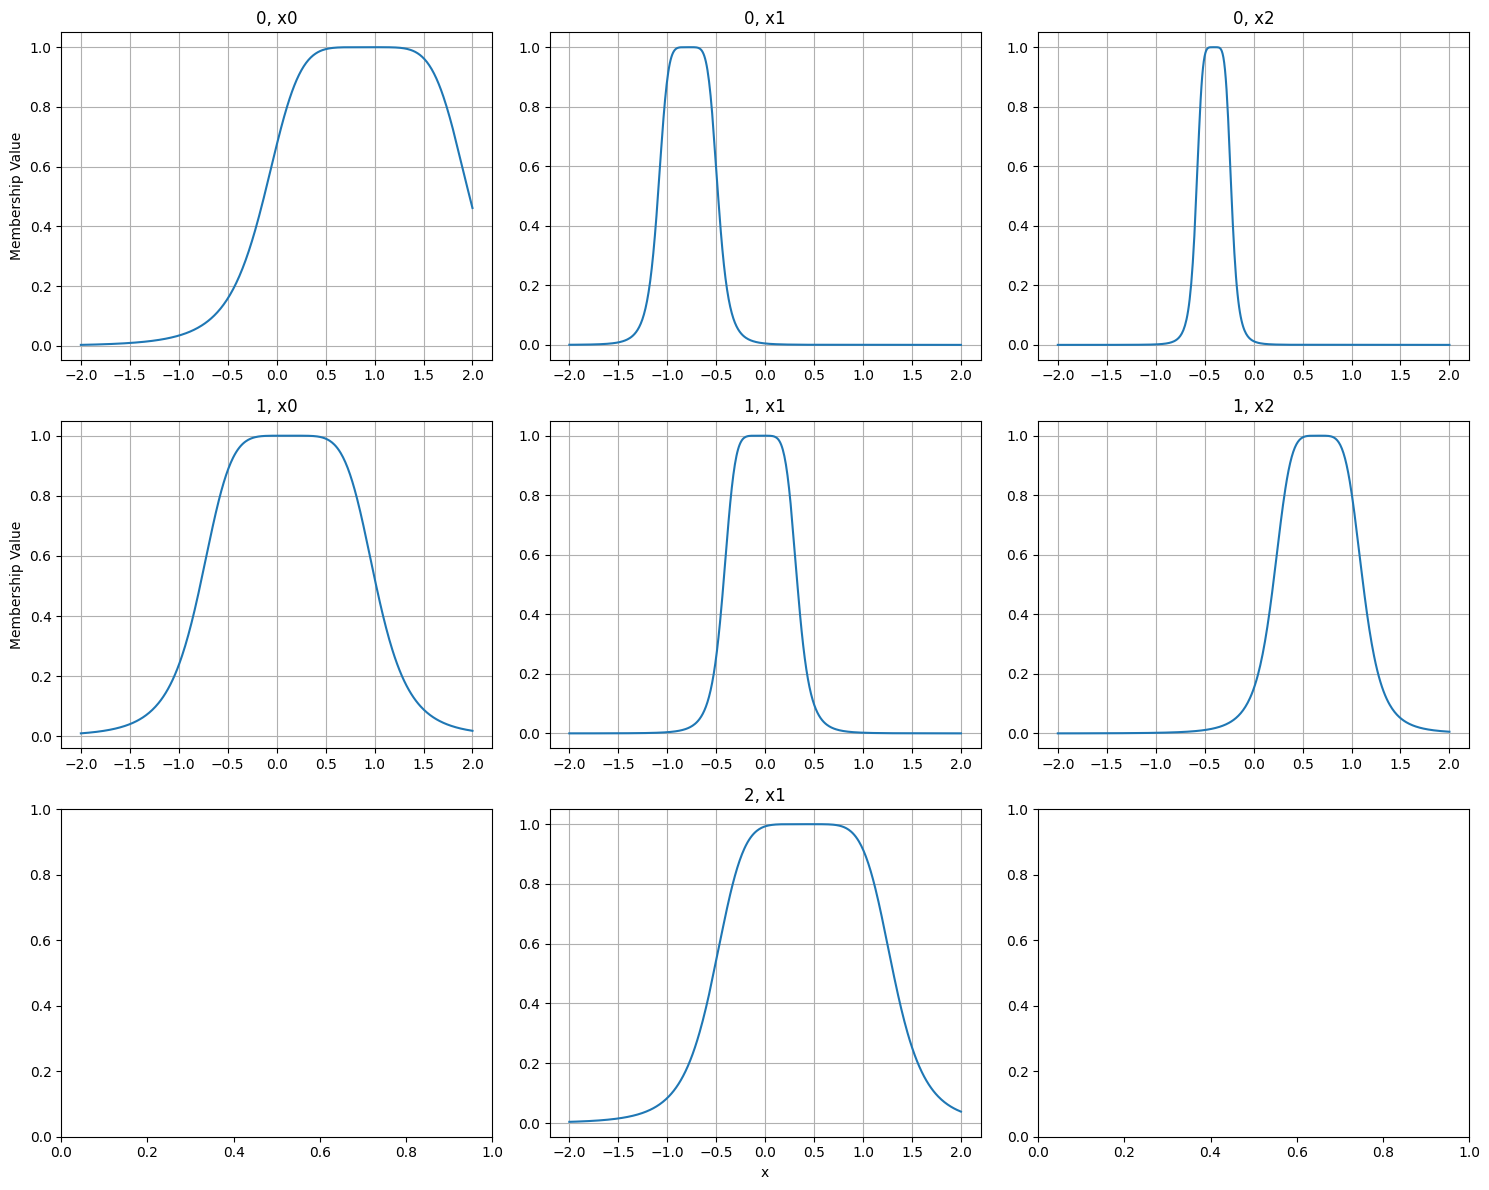

In [33]:
model.plot_premises()

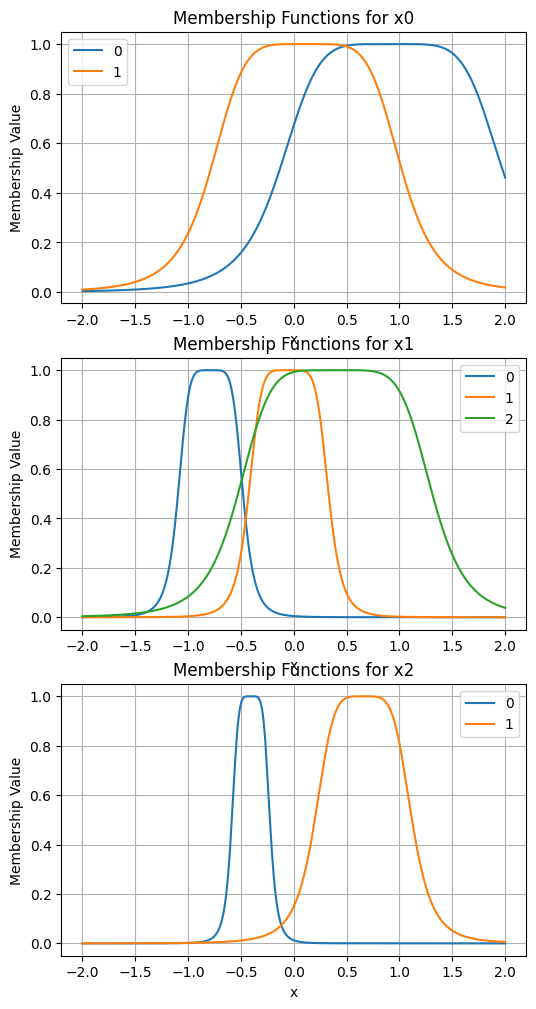

In [34]:
model.plot_premises(group_by_dim=True)

In [35]:
model.init_premises(x_train)

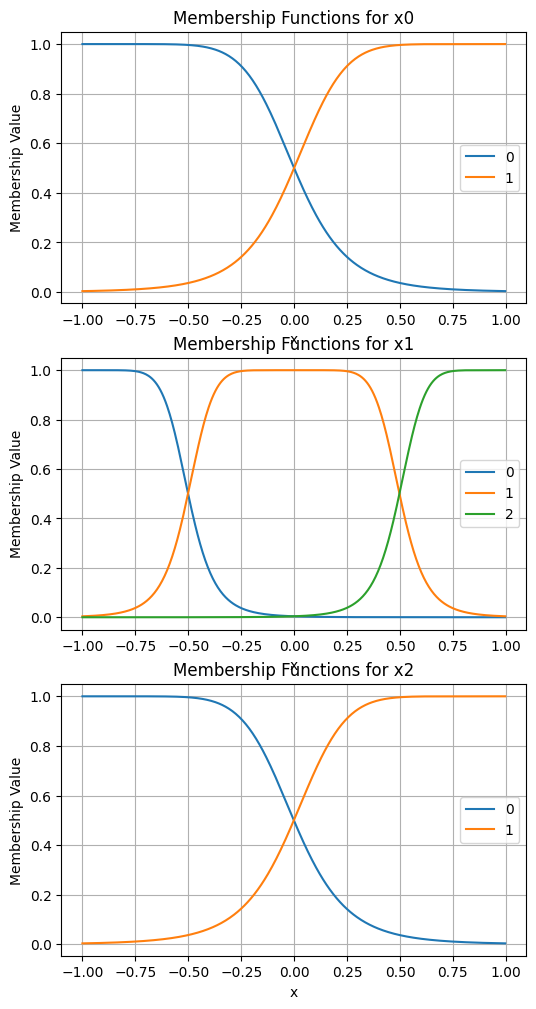

In [36]:
model.plot_premises(group_by_dim=True)

In [38]:
model.get_premises_structure()

x0                       x1                       x2               
          a    b         c         a    b         c         a    b         c
0  0.988851  4.0 -0.988809  0.499095  4.0 -0.999729  0.996328  4.0 -0.997488
1  0.988851  4.0  0.988892  0.499095  4.0 -0.001539  0.996328  4.0  0.995168
2       NaN  NaN       NaN  0.499095  4.0  0.996652       NaN  NaN       NaN

In [39]:
model.get_premises()

[tensor([[ 0.9889,  4.0000, -0.9888],
         [ 0.9889,  4.0000,  0.9889]]),
 tensor([[ 4.9910e-01,  4.0000e+00, -9.9973e-01],
         [ 4.9910e-01,  4.0000e+00, -1.5386e-03],
         [ 4.9910e-01,  4.0000e+00,  9.9665e-01]]),
 tensor([[ 0.9963,  4.0000, -0.9975],
         [ 0.9963,  4.0000,  0.9952]])]

In [41]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,-0.778198,0.147059,-0.567000,-0.436229
rule 2,0.779880,-0.239015,-0.244740,0.641444
rule 3,0.852518,0.846768,-0.146860,-0.538069
rule 4,0.893899,0.825661,0.405343,0.505475
rule 5,0.227945,-0.380538,0.136288,-0.735268
rule 6,0.275480,-0.325381,-0.830606,-0.893188
rule 7,0.652454,-0.506386,0.684612,0.391735
rule 8,-0.007978,-0.374220,-0.992053,-0.406998
rule 9,-0.532519,-0.957589,-0.452301,0.251642


In [42]:
model.get_rules_structure()

premises                                                         \
               x0                       x1                       x2        
                a    b         c         a    b         c         a    b   
rule 1   0.988851  4.0 -0.988809  0.499095  4.0 -0.999729  0.996328  4.0   
rule 2   0.988851  4.0 -0.988809  0.499095  4.0 -0.999729  0.996328  4.0   
rule 3   0.988851  4.0 -0.988809  0.499095  4.0 -0.001539  0.996328  4.0   
rule 4   0.988851  4.0 -0.988809  0.499095  4.0 -0.001539  0.996328  4.0   
rule 5   0.988851  4.0 -0.988809  0.499095  4.0  0.996652  0.996328  4.0   
rule 6   0.988851  4.0 -0.988809  0.499095  4.0  0.996652  0.996328  4.0   
rule 7   0.988851  4.0  0.988892  0.499095  4.0 -0.999729  0.996328  4.0   
rule 8   0.988851  4.0  0.988892  0.499095  4.0 -0.999729  0.996328  4.0   
rule 9   0.988851  4.0  0.988892  0.499095  4.0 -0.001539  0.996328  4.0   
rule 10  0.988851  4.0  0.988892  0.499095  4.0 -0.001539  0.996328  4.0   
rule 11  0.988851  4.0  0.988892  0.499095  4.0  0.996652  0.996328  4.0   
rule 12  0.988851  4.0  0.988892  0.499095  4.0  0.996652  0.996328  4.0   

                  output 1 consequents                                
                                    x0        x1        x2            
                c                   c0        c1        c2        c3  
rule 1  -0.997488            -0.778198  0.147059 -0.567000 -0.436229  
rule 2   0.995168             0.779880 -0.239015 -0.244740  0.641444  
rule 3  -0.997488             0.852518  0.846768 -0.146860 -0.538069  
rule 4   0.995168             0.893899  0.825661  0.405343  0.505475  
rule 5  -0.997488             0.227945 -0.380538  0.136288 -0.735268  
rule 6   0.995168             0.275480 -0.325381 -0.830606 -0.893188  
rule 7  -0.997488             0.652454 -0.506386  0.684612  0.391735  
rule 8   0.995168            -0.007978 -0.374220 -0.992053 -0.406998  
rule 9  -0.997488            -0.532519 -0.957589 -0.452301  0.251642  
rule 10  0.995168             0.888470  0.046278 -0.264733  0.582375  
rule 11 -0.997488            -0.274082  0.956698  0.369552 -0.842344  
rule 12  0.995168             0.233418 -0.768278  0.791011 -0.664895

## Binary output

In [43]:
x_train = 2 * torch.rand(200, 3) - 1

In [44]:
x_train[:10]

tensor([[-0.2086, -0.0452, -0.3268],
        [ 0.7070,  0.8279, -0.3770],
        [-0.5519, -0.5764, -0.4597],
        [ 0.2775,  0.1435, -0.3545],
        [ 0.8465,  0.4675, -0.9812],
        [-0.8301, -0.3609,  0.0045],
        [ 0.1639, -0.6528,  0.5457],
        [ 0.5486,  0.5181,  0.8751],
        [ 0.8272,  0.0990, -0.1289],
        [-0.3283, -0.6198, -0.9319]])

In [45]:
mf_distribution

[2, 3, 2]

In [46]:
bin_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    output_type='sigmoid', # Tipo de salida: clasificación binaria
)

In [47]:
bin_model.get_premises()

[tensor([[ 0.8592,  2.8549,  0.4435],
         [ 0.1255,  2.9529, -0.0938]]),
 tensor([[ 0.8063,  2.4325, -0.0174],
         [ 0.2764,  2.8250, -0.8682],
         [ 0.4988,  2.9998,  0.7279]]),
 tensor([[ 1.0032,  3.0300, -0.2106],
         [ 1.0611,  2.6038, -0.3316]])]

In [48]:
bin_model.get_consequents()

tensor([[[-0.5724, -0.6976, -0.5326, -0.1231],
         [-0.3459, -0.8599,  0.4082,  0.3360],
         [-0.2846,  0.2252,  0.1696, -0.4436],
         [ 0.0473, -0.9236, -0.1563, -0.9174],
         [-0.3844, -0.6219,  0.3142, -0.2529],
         [ 0.8883, -0.1458,  0.3538, -0.1969],
         [ 0.1904,  0.8827,  0.2040, -0.6605],
         [-0.1583, -0.2942,  0.7690,  0.7015],
         [-0.1265, -0.1600,  0.2596,  0.1503],
         [ 0.6232, -0.3101,  0.5113,  0.8891],
         [ 0.5107, -0.3064,  0.3629, -0.3111],
         [ 0.5672,  0.0093, -0.4211, -0.1202]]])

In [49]:
bin_model(x_train[:10])

tensor([0.5131, 0.3549, 0.6033, 0.4605, 0.3689, 0.6728, 0.4973, 0.4218, 0.4250,
        0.5577], grad_fn=<SigmoidBackward0>)

In [50]:
bin_model.predict(x_train[:10])

array([1, 0, 1, 0, 0, 1, 0, 0, 0, 1])

## Multiclass output

In [56]:
x_train = 2 * torch.rand(200, 3) - 1

In [57]:
mul_class_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    outputs=3, # 3 clases
    output_type='softmax', # Tipo de salida: clasificación multiclase
)

In [58]:
mul_class_model(x_train[:10])

tensor([[-4.9218e-01, -3.1596e-01,  1.1011e+00],
        [-1.4860e+00,  7.0286e-01,  1.0695e+00],
        [-1.9077e-01,  2.0239e+00,  3.1896e-01],
        [-5.4556e-01,  1.0565e+00, -1.1001e+00],
        [-2.0674e-01,  6.0726e-01,  6.4971e-01],
        [-1.1676e-01,  5.5118e-01, -7.8259e-02],
        [ 3.6533e-04,  9.0723e-01,  8.9110e-01],
        [-8.8697e-02,  2.3620e-01,  6.9233e-01],
        [ 1.2523e-01,  3.9633e-01,  5.4733e-01],
        [-2.9102e-01,  7.4306e-01,  5.1612e-01]], grad_fn=<SqueezeBackward1>)

In [59]:
mul_class_model(x_train[:10], return_probabilities=True)

tensor([[0.1406, 0.1677, 0.6917],
        [0.0439, 0.3914, 0.5647],
        [0.0846, 0.7746, 0.1408],
        [0.1530, 0.7592, 0.0878],
        [0.1782, 0.4022, 0.4196],
        [0.2507, 0.4888, 0.2605],
        [0.1691, 0.4188, 0.4121],
        [0.2189, 0.3030, 0.4781],
        [0.2607, 0.3418, 0.3975],
        [0.1652, 0.4646, 0.3702]], grad_fn=<SoftmaxBackward0>)

In [60]:
mul_class_model.predict(x_train[:10])

array([2, 2, 1, 1, 2, 1, 1, 2, 2, 1])

In [62]:
mul_class_model.get_rules_structure()

premises                                                              \
               x0                            x1                            x2   
                a         b         c         a         b         c         a   
rule 1   0.489275  2.262182 -0.726396  0.739487  3.075023  0.768958  0.328544   
rule 2   0.489275  2.262182 -0.726396  0.739487  3.075023  0.768958  0.408331   
rule 3   0.489275  2.262182 -0.726396  0.702470  2.237514  0.033855  0.328544   
rule 4   0.489275  2.262182 -0.726396  0.702470  2.237514  0.033855  0.408331   
rule 5   0.489275  2.262182 -0.726396  0.337052  2.566970  0.432960  0.328544   
rule 6   0.489275  2.262182 -0.726396  0.337052  2.566970  0.432960  0.408331   
rule 7   0.320627  2.460873  0.875432  0.739487  3.075023  0.768958  0.328544   
rule 8   0.320627  2.460873  0.875432  0.739487  3.075023  0.768958  0.408331   
rule 9   0.320627  2.460873  0.875432  0.702470  2.237514  0.033855  0.328544   
rule 10  0.320627  2.460873  0.875432  0.702470  2.237514  0.033855  0.408331   
rule 11  0.320627  2.460873  0.875432  0.337052  2.566970  0.432960  0.328544   
rule 12  0.320627  2.460873  0.875432  0.337052  2.566970  0.432960  0.408331   

                            output 1 consequents  ...                      \
                                              x0  ...        x2             
                b         c                   c0  ...        c2        c3   
rule 1   2.416279  0.126955             0.670068  ... -0.147715  0.818112   
rule 2   2.236013 -0.766445            -0.572421  ...  0.991395  0.116849   
rule 3   2.416279  0.126955             0.710312  ... -0.374569  0.177519   
rule 4   2.236013 -0.766445             0.967639  ...  0.047409 -0.213789   
rule 5   2.416279  0.126955             0.971946  ... -0.156224 -0.507059   
rule 6   2.236013 -0.766445             0.258589  ...  0.749861  0.744632   
rule 7   2.416279  0.126955             0.036866  ... -0.564751  0.690538   
rule 8   2.236013 -0.766445             0.971822  ... -0.855256 -0.085738   
rule 9   2.416279  0.126955             0.160804  ...  0.538286 -0.916679   
rule 10  2.236013 -0.766445            -0.459237  ...  0.111797 -0.079688   
rule 11  2.416279  0.126955            -0.761072  ...  0.390255 -0.452506   
rule 12  2.236013 -0.766445             0.799758  ... -0.009862  0.211897   

        output 2 consequents                                \
                          x0        x1        x2             
                          c0        c1        c2        c3   
rule 1             -0.548746  0.351333 -0.782191  0.299332   
rule 2             -0.607551  0.845642 -0.985303  0.825687   
rule 3              0.769542 -0.446367  0.805173 -0.008894   
rule 4             -0.017983  0.000390 -0.253217  0.434912   
rule 5              0.809924  0.060169 -0.217856  0.906672   
rule 6              0.056859 -0.725533  0.729861 -0.342758   
rule 7              0.511696 -0.356357 -0.467147  0.772458   
rule 8             -0.232525 -0.088712  0.834582  0.602732   
rule 9             -0.181018 -0.438975 -0.674717  0.980273   
rule 10             0.901747 -0.656791  0.127203  0.459705   
rule 11             0.534288 -0.396585  0.905288  0.615040   
rule 12            -0.229506  0.665281 -0.455229  0.457139   

        output 3 consequents                                
                          x0        x1        x2            
                          c0        c1        c2        c3  
rule 1             -0.254118  0.341264 -0.748600  0.278091  
rule 2             -0.513038 -0.185164 -0.795552 -0.383451  
rule 3             -0.732917  0.636165  0.336429  0.789994  
rule 4             -0.351339 -0.368162 -0.325102  0.091504  
rule 5              0.306703 -0.303083  0.473145  0.528448  
rule 6              0.725660 -0.328857 -0.438039 -0.002733  
rule 7             -0.680939  0.299017 -0.607403  0.719849  
rule 8              0.652286  0.050132 -0.150412 -0.545999  
rule 9              0.451220 -0.842